In [ ]:
import pandas as pd
import sqlite3
import re
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

### Introduction

The famous hosts of the German podcast "Gemischtes Hack" have recently hypothesized (Episode "Deutsche Water Gate") that the length of their episodes are getting longer. I want to find out: is that true?  
To find an answer, I have retrieved relevant data from the Spotify API. My idea is to do a simple regression analysis with time as the independent and episode length as the dependent variable, since that is exactly what the hypothesis is about.  
The podcast is published weekly since 2017. The analysis was done at the end of March 2026.

In [345]:
# Read SQL table with data
con = sqlite3.connect("episodes.db")
df = pd.read_sql("select * from episodes", con, index_col="id", parse_dates="release_date", dtype={"duration_ms": "int32", "explicit": "bool"})

In [346]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 353 entries, 1 to 353
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   name          353 non-null    str           
 1   description   353 non-null    str           
 2   release_date  353 non-null    datetime64[us]
 3   duration_ms   353 non-null    int32         
 4   explicit      353 non-null    bool          
 5   spotify_id    353 non-null    str           
dtypes: bool(1), datetime64[us](1), int32(1), str(3)
memory usage: 12.9 KB


The dataset includes 
- the name of the episode
- the description of the episode
- the release date
- the episode length in ms (later converted to minutes)
- if the episode is marked as explicit content or not
- the spotify id of the episode

The description is important to have some context, if specific episodes must be looked into.

In [347]:
# Scale episode duration to a more readable format
df = df.assign(duration_min=df.duration_ms / 60000,
               days_since_first=(df["release_date"] - df["release_date"].min()).dt.days,
               weeks_since_first=lambda x: x.days_since_first / 7)


In [348]:
# Work with necessary columns only and sort to have first episode on top
time_df = df[["weeks_since_first", "release_date", "duration_min", "description"]].set_index("release_date")
time_df.sort_index(inplace=True)

In [349]:
print(f"Number of missing values per column:\n{time_df.isna().sum()}")

Number of missing values per column:
weeks_since_first    0
duration_min         0
description          0
dtype: int64


In [350]:
print(f"Number of unique release dates: {time_df.index.nunique()} (corresponds to number of rows)")

Number of unique release dates: 353 (corresponds to number of rows)


In [351]:
print(f"Latest episode released on (in this dataset): {time_df.index.max()}")

Latest episode released on (in this dataset): 2026-03-24 00:00:00


In [369]:
print(f"First episode released on: {time_df.index.min()}")

First episode released on: 2017-09-27 00:00:00


## Regression Assumptions

### 1. Homoskedasticity and linear relationship

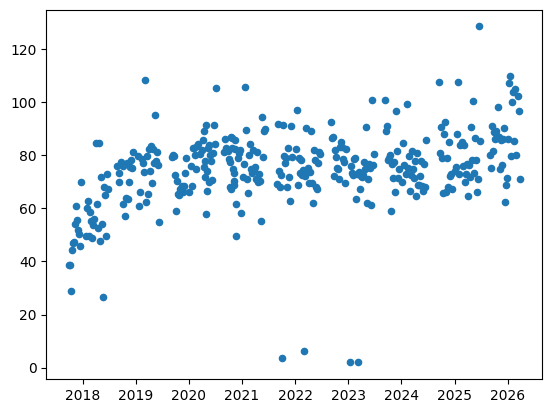

In [352]:
plt.scatter(x=time_df.index, y=time_df.duration_min, s=20);

The scatter plot shows a healthy linear relationship between the independent variable time and the dependent variable episode length (duration_ms). There are some outliers, most interestingly 4 outliers with extremely low durations. These might be irregular episodes, where one party was sick. The episodes then only say that there will not be a normal episode. We can verify this by looking at the descriptions of those extreme case episodes.
There is no clear pattern, except maybe a slight funnel towards the end, therefore, I would say that homoskedasticity is also given. 

### Normal distribution of residuals

In [353]:
# Baseline model
x = sm.add_constant(time_df["weeks_since_first"])
Y = time_df["duration_min"]
model = sm.OLS(Y, x).fit()


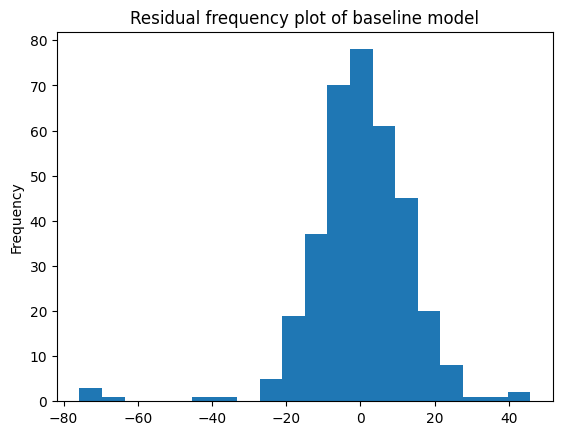

In [354]:
# Plot residuals of baseline model
residuals = model.resid
residuals.plot.hist(bins=20, title="Residual frequency plot of baseline model");

The histogram of the residuals shows a normal distribution. We can clearly see the outliers with very small durations on the left, but also some other rare cases of very small/big residuals. However, these could just indicate exceptionally long/short episodes.  
The normality of the distribution could be improved by looking at the outliers.

### Outlier Analysis

#### Removing abnormal data points

In [355]:
# Filter df to short episodes (looked at the scatter plot)
short_length_episodes = time_df.loc[time_df["duration_min"] < 20]

In [356]:
# Systematically look for keywords in filtered episode descriptions
short_length_episodes.description.str.contains("(krank|gesundheitliche. Gründe|fällt aus|ausfallen)", flags=re.IGNORECASE, regex=True)

/var/folders/nr/0hn3dgyx747gcslq_4d2p8vw0000gn/T/ipykernel_62165/2236254539.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  short_length_episodes.description.str.contains("(krank|gesundheitliche. Gründe|fällt aus|ausfallen)", flags=re.IGNORECASE, regex=True)


release_date
2021-10-05    True
2022-03-01    True
2023-01-10    True
2023-03-07    True
Name: description, dtype: bool

Looking at the episode descriptions of the episodes with less than 20 min, we can verify that they were irregular due to the hosts being sick. I used the (German) key words "sick", "health reasons" and "cancelled" to filter the descriptions. Since these episodes are not regular and will influence the analysis, they are removed from the dataset.

In [357]:
# Removing the first outliers
over_20_time_df = time_df.loc[time_df["duration_min"] >= 20]
print(f"Removing 4 outliers - new nrows: {over_20_time_df.shape[0]}")

Removing 4 outliers - new nrows: 349


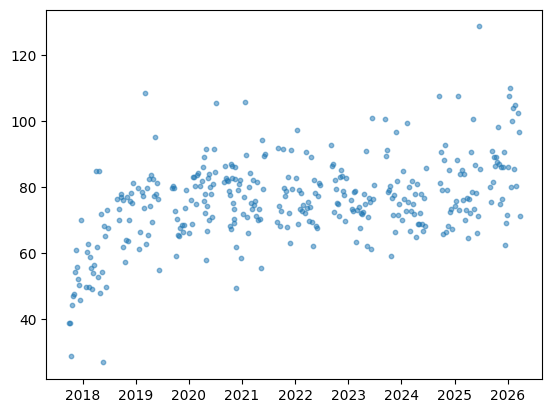

In [358]:
plt.scatter(x=over_20_time_df.index, y=over_20_time_df.duration_min, s=10, alpha=0.5);

In [359]:
# New model without outliers
x_20 = sm.add_constant(over_20_time_df.weeks_since_first)
Y_20 = over_20_time_df["duration_min"]

model_over_20 = sm.OLS(Y_20, x_20).fit()


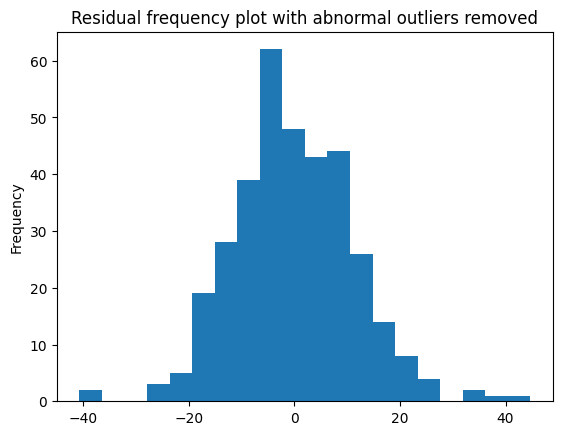

In [360]:
residuals_20 = model_over_20.resid
residuals_20.plot.hist(bins=20, title="Residual frequency plot with abnormal outliers removed");

#### Handling further extreme data points

In [361]:
# Short episodes (< 40 min)
over_20_time_df.loc[over_20_time_df["duration_min"] < 40]

,weeks_since_first,duration_min,description
release_date,,,
2017-09-27,0.000000,38.737050,#1 GEMISCHTES HACK by Felix Lobrecht & Tommi S...
2017-10-04,1.000000,38.787917,#2 BEREICHSLEITER by Felix Lobrecht & Tommi Sc...
2017-10-10,1.857143,28.856150,#3 ALLE ASTRONAUTEN SIND ALKOHOLIKER by Felix ...
2018-05-22,33.857143,26.759833,#30 ÜBERRASCHUNGSHACK by Felix Lobrecht & Tomm...


There are some other shorter episodes (< 40 min) visible in the scatter plot, but the descriptions do not indicate any irregularity. It is notable that these are the first episodes ever and the 30th episode, so when the podcast was at very early stages. There is not a good reason to remove them as I did with the others before. I will still make a model without episodes 1, 2, 3 and 30 out of curiosity.

In [362]:
# Model only with episodes over 40 minutes
over_40_time_df = over_20_time_df.loc[over_20_time_df["duration_min"] >= 40]

x_40 = sm.add_constant(over_40_time_df.weeks_since_first)
Y_40 = over_40_time_df["duration_min"]

model_over_40 = sm.OLS(Y_40, x_40).fit()

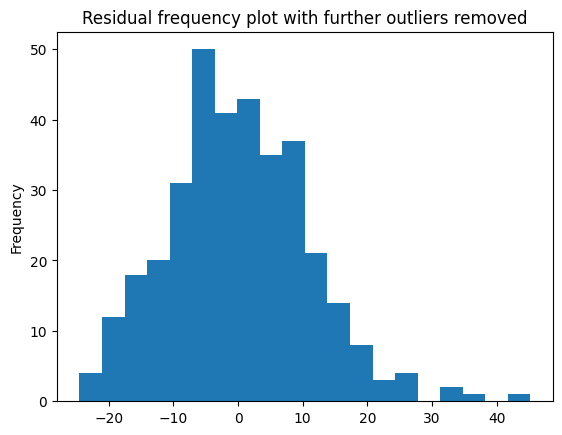

In [363]:
residuals_40 = model_over_40.resid
residuals_40.plot.hist(bins=20, title="Residual frequency plot with further outliers removed");

### Independence of data points & no autocorrelation

It is difficult to measure how the length of one episode length impacts the next. We can use the Durbin-Watson test to verify that there is no auto correlation in the time series. A value of 2 means no auto correlation, while 0 is positive auto correlation and 4 is negative auto correlation.

In [364]:
print(f"Model with no episodes < 20 min:\nDurbin-Watson test: {durbin_watson(model_over_20.resid):.3f}\n")
print(f"Model with no episodes < 40 min:\nDurbin-Watson test: {durbin_watson(model_over_40.resid):.3f}")

Model with no episodes < 20 min:
Durbin-Watson test: 1.507

Model with no episodes < 40 min:
Durbin-Watson test: 1.618


The requirements for the regression analysis are mostly satisfied. Just the variance of the residuals increase a little towards the end. The model filtering out more outliers does have a better normal distribution, homoskedasticity and less autocorrelation, but it leaves out episodes with no good explanation. Therefore, the other model still preferable.

### Model summaries

#### All episodes over 20 minutes

In [365]:
print(f"Parameters:\n{model_over_20.params}\n")
print(f"P values:\n{model_over_20.pvalues}\n")
print(f"R2:\n{model_over_20.rsquared.round(3)}")

Parameters:
const                65.970985
weeks_since_first     0.044474
dtype: float64

P values:
const                2.195689e-171
weeks_since_first     1.099757e-18
dtype: float64

R2:
0.201


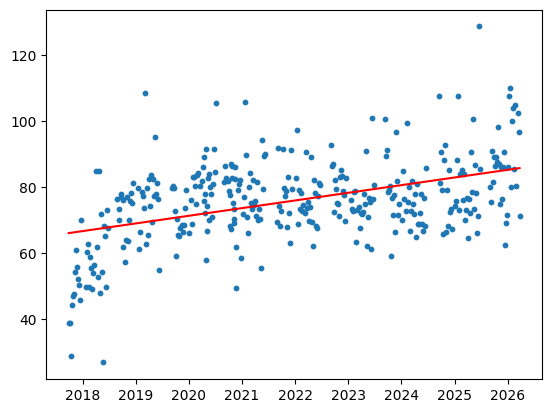

In [366]:
plt.scatter(x=over_20_time_df.index, y=over_20_time_df["duration_min"], s=10)
plt.plot(over_20_time_df.index, model_over_20.fittedvalues, c="red");


#### All episodes over 40 minutes

In [367]:
print(f"Parameters:\n{model_over_40.params}\n")
print(f"P values:\n{model_over_40.pvalues}\n")
print(f"R2:\n{model_over_40.rsquared.round(3)}")

Parameters:
const                67.479273
weeks_since_first     0.039448
dtype: float64

P values:
const                6.862299e-177
weeks_since_first     3.520018e-16
dtype: float64

R2:
0.176


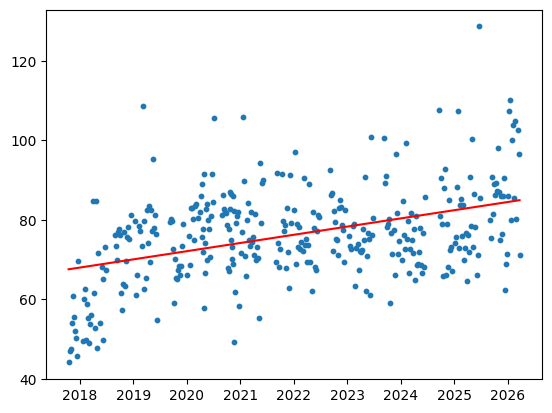

In [368]:
plt.scatter(x=over_40_time_df.index, y=over_40_time_df["duration_min"], s=10)
plt.plot(over_40_time_df.index, model_over_40.fittedvalues, c="red");

Both models have highly significant coefficients (with p values close to 0). Over time, episode lengths have indeed increased (Every week by about 0.04 minutes)  Looking at the pretty low R-Squared values, we can also say that time does not explain the variable episode length very well. It would be interesting to analyze possible other factors influencing episode length. I believe they are more subjective, such as the mood of the podcast hosts or their activities and duties besides the podcast.